# Representation and Description

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread("leaf.png", cv2.IMREAD_GRAYSCALE)
img

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(352, 326), dtype=uint8)

## Chain Code

Start[y,x]= (10, 162)

Chain Code:
[6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 5, 5, 5, 4, 4, 4, 3, 4, 3, 4, 3, 4, 3, 3, 4, 3, 4, 3, 4, 3, 3, 4, 3, 4, 3, 3, 4, 3, 4, 3, 4, 3, 3, 4, 6, 6, 6, 7, 6, 6, 6, 6, 7, 6, 6, 6, 6, 7, 6, 6, 6, 6, 6, 7, 6, 6, 6, 6, 7, 6, 6, 6, 6, 7, 6, 6, 6, 6, 7, 6, 6, 6, 6, 7, 6, 6, 6, 6, 7, 6, 6, 6, 6, 6, 7, 6, 6, 6, 6, 7, 6, 6, 6, 6, 7, 6, 6, 6, 6, 7, 6, 6, 6, 6, 7, 6, 6, 6, 6, 7, 6, 6, 6, 6, 6, 7, 6, 6, 6, 6, 7, 6, 5, 6, 5, 5, 5, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 5, 6, 5, 6, 5, 6, 6, 5, 6, 5, 6, 5, 6, 6, 5, 6, 5, 6, 6, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 3, 4, 4, 4, 4, 3, 4, 4, 4, 3, 4, 4, 4, 4, 3, 4, 4, 4, 4, 3, 4, 4, 4, 3, 4, 4, 4, 4, 3, 4, 4, 4, 4, 3, 4, 4, 6, 6, 7, 6, 6, 6, 7, 6, 6, 7, 6, 6, 7, 6, 6, 7, 6, 6, 7, 6, 6, 7, 6, 6, 7, 6, 6, 7, 6, 6

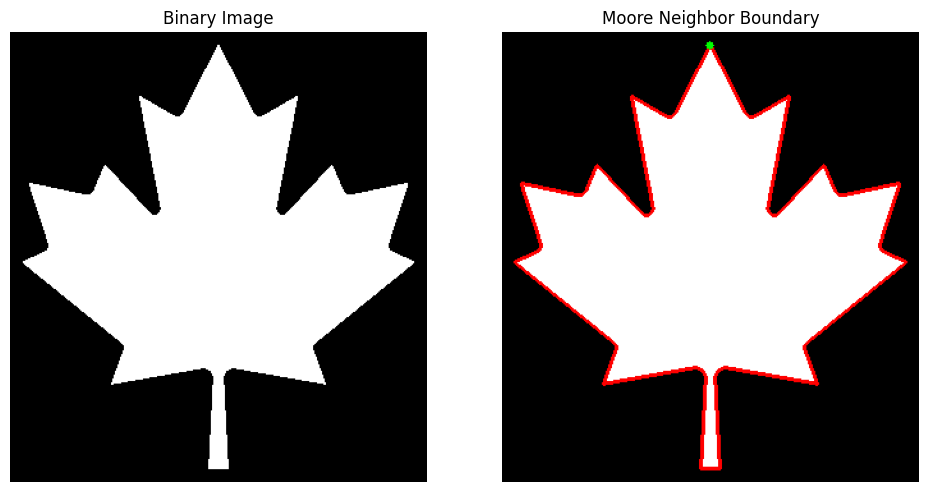

In [6]:
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
rows, cols = binary.shape

dirs = [
    (0, 1),  # 0
    (-1, 1), # 1
    (-1, 0), # 2
    (-1, -1),# 3
    (0, -1), # 4
    (1, -1), # 5
    (1, 0),  # 6
    (1, 1)   # 7
]

start = None
for i in range(rows):
    found = False
    for j in range(cols):
        if binary[i, j] != 255: # considering white object with black background
            continue
        for dx, dy in dirs:   # Check whether pixel is on boundary
            x = i + dx
            y = j + dy
            if x < 0 or x >= rows or y < 0 or y >= cols:
                start = (i, j)
                found = True
                break
            if binary[x, y] == 0:
                start = (i, j)
                found = True
                break
        if found:
            break
    if found:
        break

if start is None:
    print("Object Not Found")

print("Start[y,x]=", start)

boundary = [start]
chain_code = []

current = start
prev_dir = 4

while True:
    found = False
    for k in range(8):    # Moore neighbor search
        direction = (prev_dir + 1 + k) % 8
        dx, dy = dirs[direction]
        nx = current[0] + dx
        ny = current[1] + dy

        if nx < 0 or ny < 0 or nx >= rows or ny >= cols:
            continue

        if binary[nx, ny] == 255:

            boundary.append((nx, ny))
            chain_code.append(direction)
            current = (nx, ny)
            
            prev_dir = (direction + 5) % 8  #Next search begins from opposite side on compass
            found = True
            break
    if not found:
        break
    if current == start and len(boundary) > 2:
        break

print("\nChain Code:")
print(chain_code)
print("\nLength =", len(chain_code))

output = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)

for p in boundary:
    cv2.circle(output, (p[1], p[0]), 1, (0,0,255), -1) #traced bounadry pixels

cv2.circle(output, (start[1], start[0]), 3, (0,255,0), -1) #highlighting boundary description 

plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis("off")

plt.subplot(122)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Moore Neighbor Boundary")
plt.axis("off")

plt.tight_layout()
plt.show()

## Shape Number

In [9]:
chain_code = [5, 6, 6, 6, 7, 7, 0, 0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 4]

print("Chain Code: ",chain_code)

first_difference = [] # First Difference d(i) = (c(i+1)-c(i)) mod 8
n = len(chain_code)

for i in range(n):
    diff = (chain_code[(i+1)%n] - chain_code[i]) % 8
    first_difference.append(diff)

print("\nFirst Difference:",first_difference)

rotations = [] # circular shifts

for i in range(n):
    rotated = first_difference[i:] + first_difference[:i]
    rotations.append(rotated)

print("\nAll Circular Rotations:")
for r in rotations: 
    print(r)

shape_number = min(rotations) # Lexicographical order - Find smallest rotation

print("\nShape Number:")
print(shape_number)

Chain Code:  [5, 6, 6, 6, 7, 7, 0, 0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 4]

First Difference: [1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1]

All Circular Rotations:
[1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1]
[0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1]
[0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0]
[1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0]
[0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1]
[1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0]
[0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1]
[0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0]
[1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0]
[0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1]
[1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0]
[0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1]
[1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0]
[0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1]
[1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0]
[0, 0, 1

## Signature

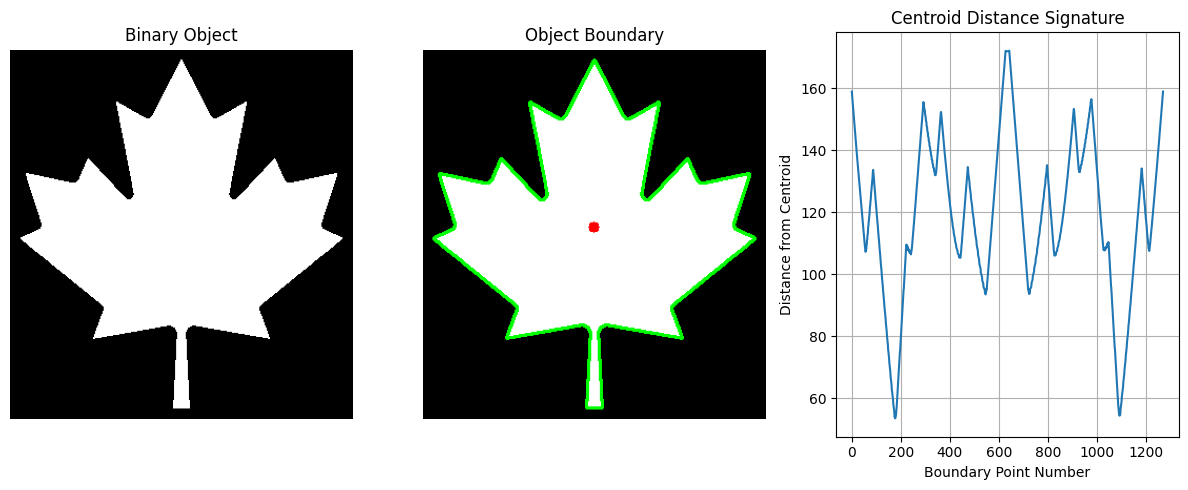

In [15]:
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
contour = max(contours, key=cv2.contourArea) # Select largest contour
M = cv2.moments(contour) # Calculate Centroid

cx = int(M["m10"] / M["m00"])
cy = int(M["m01"] / M["m00"])

signature = []

for point in contour:
    x, y = point[0]
    distance = np.sqrt((x - cx)**2 + (y - cy)**2)
    signature.append(distance)

output = img.copy()
output = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
cv2.drawContours(output, [contour], -1, (0,255,0), 2) #boundary highlight
cv2.circle(output, (cx,cy), 5, (0,0,255), -1) # center

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(binary, cmap = "gray")
plt.title("Binary Object")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Object Boundary")
plt.axis("off")

plt.subplot(1,3,3)
plt.plot(signature)
plt.title("Centroid Distance Signature")
plt.xlabel("Boundary Point Number")
plt.ylabel("Distance from Centroid")
plt.grid(True)

plt.tight_layout()
plt.show()

## Fourier Descriptors

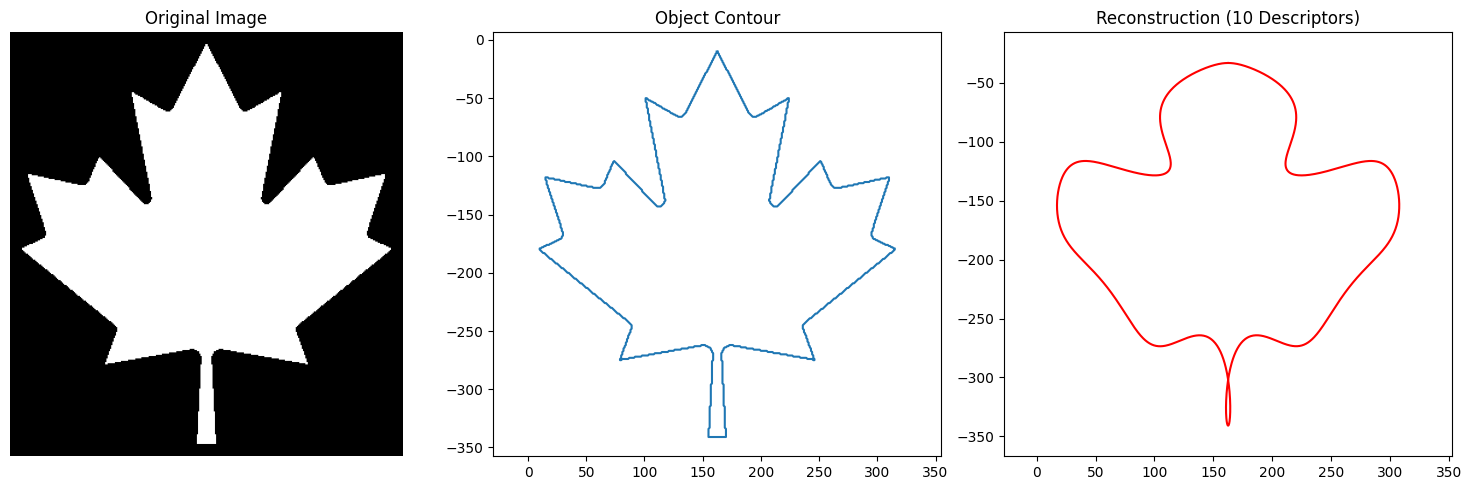

In [22]:
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

contour = max(contours, key=cv2.contourArea)

points = contour[:, 0, :] # Convert contour to complex numbers
complex_points = points[:,0] + 1j * points[:,1]

fd = np.fft.fft(complex_points) # Fourier Descriptor
magnitude = np.abs(fd)

num_descriptors = 10 # num_descriptors derines reconstructed shape

fd_reduced = np.zeros_like(fd)

center = len(fd)//2

fd_reduced[:num_descriptors] = fd[:num_descriptors]
fd_reduced[-num_descriptors:] = fd[-num_descriptors:]

reconstructed = np.fft.ifft(fd_reduced) # Reconstructed Contour

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.plot(points[:,0], -points[:,1])
plt.title("Object Contour")
plt.axis("equal")

plt.subplot(1,3,3)
plt.plot(reconstructed.real, -reconstructed.imag, 'r')
plt.title(f"Reconstruction ({num_descriptors} Descriptors)")
plt.axis("equal")

plt.tight_layout()
plt.show()